# 📚 K-Nearest Neighbors (KNN) Algorithm

**K-Nearest Neighbors (KNN)** is a simple, non-parametric, and instance-based learning algorithm used for **classification** and **regression** tasks. It is often considered one of the most straightforward machine learning algorithms.


<div style="text-align: center;">
  <a href="https://colab.research.google.com/github/MinooSdpr/Machine-Learning-101/blob/main/Session%2013/Session%2013_1%20-%20K%20Nearest%20Neighbors%20with%20Python.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" />
  </a>
  &nbsp;
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2013/Session%2013_1%20-%20K%20Nearest%20Neighbors%20with%20Python.ipynb">
    <img src="https://img.shields.io/badge/Open%20in-GitHub-24292e?logo=github&logoColor=white" alt="Open In GitHub" />
  </a>
</div>

## How does it work?

Given a new data point that we want to classify or predict, the KNN algorithm follows these steps:

1. **Choose the number of neighbors**: Select a value for `K`, the number of nearest neighbors to consider.
2. **Calculate distance**: Compute the distance between the new data point and all the points in the training dataset (commonly using Euclidean distance).
3. **Find K nearest neighbors**: Identify the `K` data points in the training set that are closest to the new data point.
4. **Make a prediction**:
   - For **classification**: Take a **majority vote** among the `K` neighbors.
   - For **regression**: Take the **average** of the values of the `K` neighbors.

## Characteristics of KNN

- **Lazy learning**: KNN does not build a model during training. It memorizes the training dataset and only computes predictions when needed.
- **No assumptions**: KNN makes no underlying assumptions about data distribution.
- **Sensitive to scale**: Since it relies on distance metrics, feature scaling is crucial for accurate results.

## Choosing the Right K

- A small `K` (e.g., 1) can be **noisy** and lead to overfitting.
- A large `K` may **smooth** out the boundaries too much and lead to underfitting.
- Typically, odd values of `K` are used to avoid ties in classification.


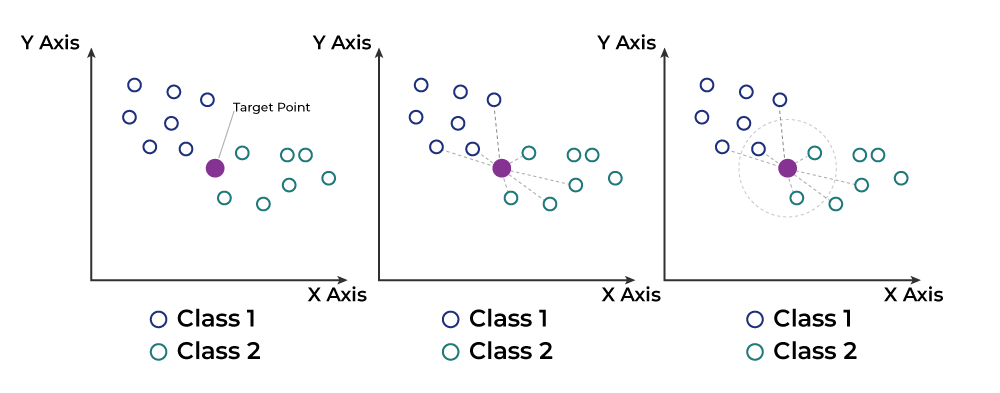

## Import Libraries



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

sns.set(style='whitegrid')

## Get the Data

Set index_col=0 to use the first column as the index.

In [2]:
df = pd.read_csv("Classified Data",index_col=0)
df.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


## 🔄 Standardizing the Variables

Before applying the K-Nearest Neighbors (KNN) algorithm, it's important to **standardize the features** in our dataset.

### Why Standardization?

KNN is a **distance-based algorithm**, which means it relies on calculating distances (e.g., Euclidean) between data points. If the features have different scales, those with larger ranges will **dominate the distance calculation**, leading to biased or inaccurate results.

For example:
- Feature A ranges from 0 to 1
- Feature B ranges from 0 to 1000

In this case, feature B would outweigh feature A in distance computation, even if A is more important.

### What is Standardization?

Standardization transforms each feature to have:
- A **mean of 0**
- A **standard deviation of 1**

This is done using the formula:

$$z = \frac{x - \mu}{\sigma}$$

Where:
- $x$ is the original value
- $mu$ is the mean of the feature
- $sigma$ is the standard deviation of the feature


> ⚠️ Note: We **fit the scaler on the training set only** and **apply the same transformation to the test set**. This avoids data leakage.


In [3]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df.drop('TARGET CLASS',axis=1))
scaled_features = scaler.transform(df.drop('TARGET CLASS',axis=1))

In [4]:
df_feat = pd.DataFrame(scaled_features,columns=df.columns[:-1])
df_feat.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ
0,-0.123542,0.185907,-0.913431,0.319629,-1.033637,-2.308375,-0.798951,-1.482368,-0.949719,-0.643314
1,-1.084836,-0.430348,-1.025313,0.625388,-0.444847,-1.152706,-1.129797,-0.202240,-1.828051,0.636759
2,-0.788702,0.339318,0.301511,0.755873,2.031693,-0.870156,2.599818,0.285707,-0.682494,-0.377850
3,0.982841,1.060193,-0.621399,0.625299,0.452820,-0.267220,1.750208,1.066491,1.241325,-1.026987
4,1.139275,-0.640392,-0.709819,-0.057175,0.822886,-0.936773,0.596782,-1.472352,1.040772,0.276510


## Train Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(scaled_features,df['TARGET CLASS'], test_size=0.30)

## 🤖 KNeighborsClassifier


Given a new data point, the classifier:
1. Finds the **K closest training examples** to the new point based on a distance metric.
2. Looks at the **labels of these neighbors**.
3. Assigns the class that is the **most common among those neighbors** to the new data point.

### Important Parameters of `KNeighborsClassifier`

| Parameter        | Description                                                                                   | Default     |
|------------------|-----------------------------------------------------------------------------------------------|-------------|
| `n_neighbors`    | Number of neighbors to use for classification. The value of **K** in KNN.                      | 5           |
| `weights`        | Weight function used in prediction. Options:                                                | `'uniform'` |
|                  | - `'uniform'`: All neighbors are weighted equally.                                          |             |
|                  | - `'distance'`: Neighbors closer to the query point have more influence.                     |             |
| `metric`         | The distance metric used to find nearest neighbors. Common options:                          | `'minkowski'` |
|                  | - `'euclidean'` (L2 norm)                                                                    |             |
|                  | - `'manhattan'` (L1 norm)                                                                    |             |
|                  | - `'minkowski'` (generalized distance with parameter `p`)                                    |             |
| `p`              | Power parameter for the Minkowski metric. When `p=2`, this is equivalent to Euclidean distance. When `p=1`, it’s Manhattan distance. | 2           |
| `algorithm`      | Algorithm used to compute nearest neighbors:                                               | `'auto'`    |
|                  | - `'auto'`: Let the algorithm choose based on the data.                                     |             |
|                  | - `'ball_tree'`, `'kd_tree'`, `'brute'` are other options depending on dataset size & features.|             |
| `leaf_size`      | Leaf size passed to BallTree or KDTree algorithms. Affects speed of query and memory usage.  | 30          |
| `n_jobs`         | Number of parallel jobs to run for neighbors search. `-1` means using all processors.        | None        |


In [6]:
from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train,y_train)
pred = knn.predict(X_test)

## Predictions and Evaluations

Let's evaluate our KNN model!

In [7]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,pred))

[[133  18]
 [ 17 132]]


In [8]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.89      0.88      0.88       151
           1       0.88      0.89      0.88       149

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300



## Choosing a K Value

Let's go ahead and use the elbow method to pick a good K Value:

In [9]:
error_rate = []

for i in range(1,40):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Error Rate')

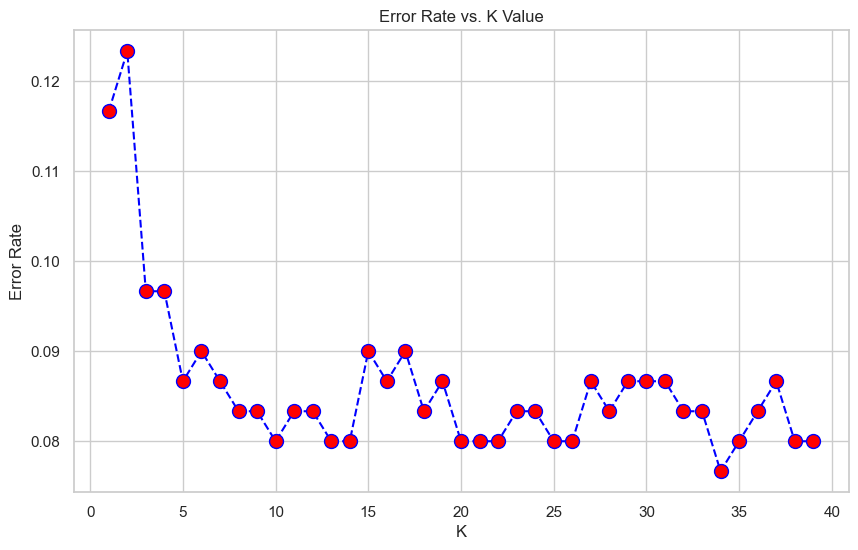

In [10]:
plt.figure(figsize=(10,6))
plt.plot(range(1,40),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [14]:
knn = KNeighborsClassifier(n_neighbors=10)

knn.fit(X_train,y_train)
pred = knn.predict(X_test)

print('WITH K=10')
print('\n')
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))

WITH K=10


[[135  16]
 [  8 141]]


              precision    recall  f1-score   support

           0       0.94      0.89      0.92       151
           1       0.90      0.95      0.92       149

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



# Great job!


<div style="float:right;">
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2013/Session%2013_2%20-%20K%20Nearest%20Neighbors%20Project.ipynb"
     style="
       display:inline-block;
       padding:8px 20px;
       background-color:#414f6f;
       color:white;
       border-radius:12px;
       text-decoration:none;
       font-family:sans-serif;
       transition:background-color 0.3s ease;
     ">
    ▶️ Next
  </a>
</div>